<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_Time_Series_Analysis_with_Autocorrelation%2C_ACF%2C_PACF%2C_AIC%2C_and_BIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing the Required Libraries
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn

In [2]:
# Uploading the Dataset
from google.colab import files
uploaded = files.upload()

Saving AirPassengers.csv to AirPassengers.csv


In [3]:
# Importting the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

In [4]:
# Loading the Dataset
df = pd.read_csv("AirPassengers.csv")

# Converting the Month column to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Setting the Month as index
df.set_index('Month', inplace=True)

# Displaying first rows
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
# Initial Data Exploration
# Checking dataset information
print("Dataset Shape:", df.shape)

# Checkign the missing values
print("\nMissing Values:\n", df.isnull().sum())

# Summary statistics
df.describe()

Dataset Shape: (144, 1)

Missing Values:
 #Passengers    0
dtype: int64


,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


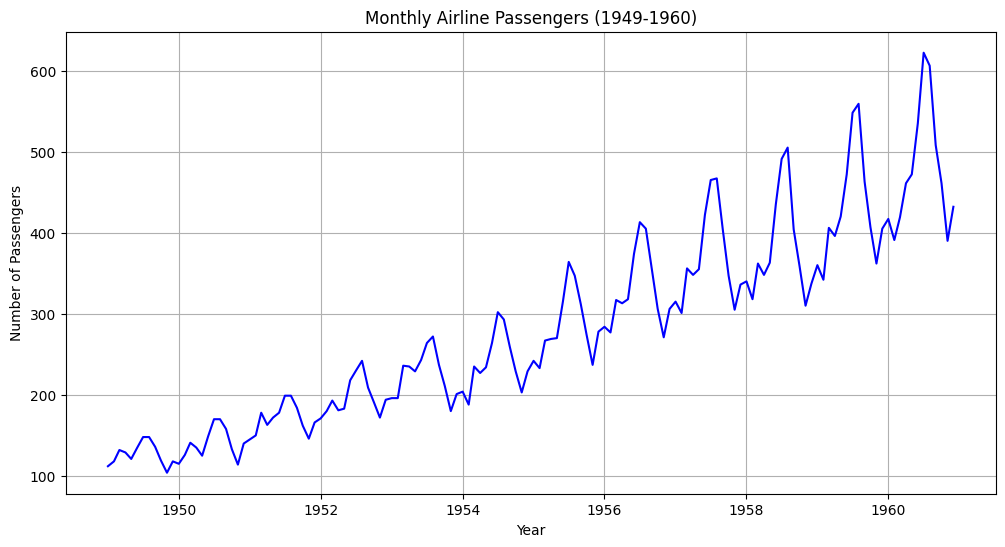

'Interpretation\n\nUpward trend\n\nPossible seasonal patterns'

In [6]:
# Time Series Visualization
plt.figure(figsize=(12,6))
plt.plot(df.index, df['#Passengers'], color='blue')
plt.title("Monthly Airline Passengers (1949-1960)")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.grid(True)
plt.show()

"""Interpretation

Upward trend

Possible seasonal patterns"""

<Figure size 1000x500 with 0 Axes>

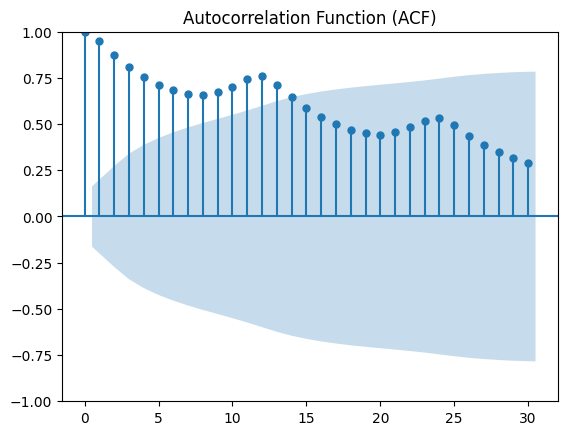

'Interpretation\n\nSignificant spikes show strong correlation with previous months\n\nSlowly decreasing correlation indicates trend in data'

In [7]:
# Autocorrelation Function (ACF)
plt.figure(figsize=(10,5))
plot_acf(df['#Passengers'], lags=30)
plt.title("Autocorrelation Function (ACF)")
plt.show()

"""Interpretation

Significant spikes show strong correlation with previous months

Slowly decreasing correlation indicates trend in data"""

<Figure size 1000x500 with 0 Axes>

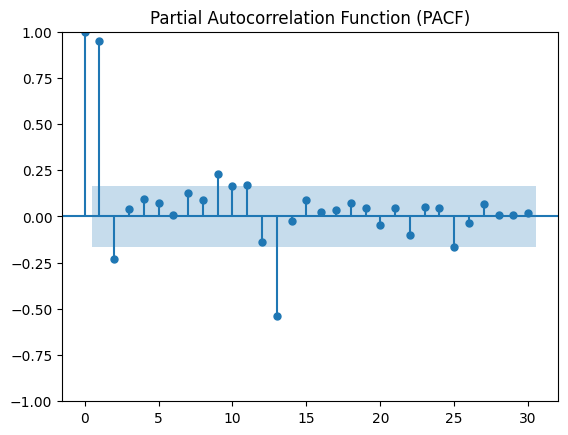

'Interpretation\n\nPACF helps determine AR model order (p)\n\nSignificant spikes suggest possible lag values'

In [8]:
# Partial Autocorrelation Function (PACF)
plt.figure(figsize=(10,5))
plot_pacf(df['#Passengers'], lags=30, method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()
"""Interpretation

PACF helps determine AR model order (p)

Significant spikes suggest possible lag values"""

In [9]:
# Train/Test Split
# Splitting dataset (80% train, 20% test)

train_size = int(len(df) * 0.8)

train = df['#Passengers'][:train_size]
test = df['#Passengers'][train_size:]

print("Training Data:", len(train))
print("Testing Data:", len(test))

Training Data: 115
Testing Data: 29


In [10]:
# Model Selection Using AIC and BIC
# Testing AR(1) to AR(10).
aic_values = []
bic_values = []
models = []

for p in range(1, 11):

    model = AutoReg(train, lags=p).fit()

    aic_values.append(model.aic)
    bic_values.append(model.bic)
    models.append(model)

# Creating the results table
results = pd.DataFrame({
    "AR Order (p)": range(1,11),
    "AIC": aic_values,
    "BIC": bic_values
})

results

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

,AR Order (p),AIC,BIC
0,1,1078.054169,1086.262764
1,2,1061.255976,1072.165527
2,3,1050.472900,1064.065394
3,4,1043.911775,1060.168956
4,5,1027.268933,1046.172295
5,6,1020.415740,1041.946524
6,7,1012.970931,1037.110112
7,8,1001.658085,1028.386374
8,9,963.757881,993.055711
9,10,950.514623,982.362147


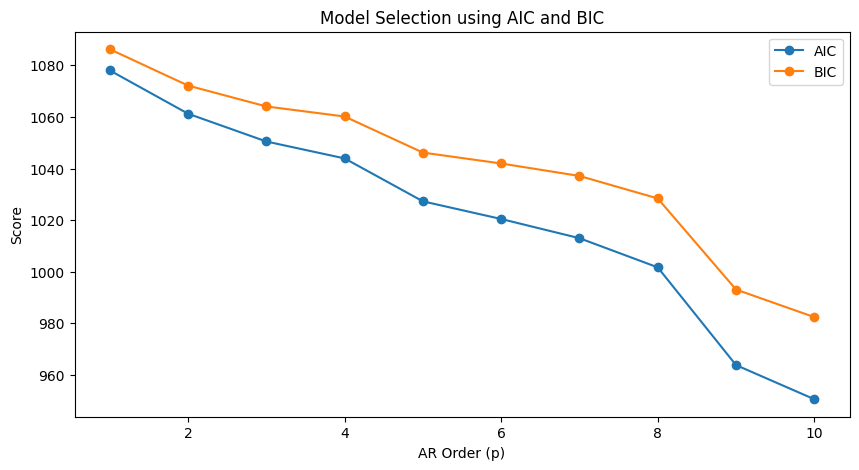

'Choosing the model with the lowest AIC and BIC'

In [11]:
# Plotting AIC and BIC
plt.figure(figsize=(10,5))

plt.plot(results["AR Order (p)"], results["AIC"], marker='o', label="AIC")
plt.plot(results["AR Order (p)"], results["BIC"], marker='o', label="BIC")

plt.xlabel("AR Order (p)")
plt.ylabel("Score")
plt.title("Model Selection using AIC and BIC")
plt.legend()

plt.show()
"""Choosing the model with the lowest AIC and BIC"""

In [12]:
# Selecting Best AR Model
best_p = results.loc[results['AIC'].idxmin(), 'AR Order (p)']

print("Best AR Order based on AIC:", best_p)

best_model = AutoReg(train, lags=int(best_p)).fit()

print(best_model.summary())

Best AR Order based on AIC: 10
                            AutoReg Model Results                             
Dep. Variable:            #Passengers   No. Observations:                  115
Model:                    AutoReg(10)   Log Likelihood                -463.257
Method:               Conditional MLE   S.D. of innovations             19.946
Date:                Sun, 08 Mar 2026   AIC                            950.515
Time:                        21:46:03   BIC                            982.362
Sample:                    11-01-1949   HQIC                           963.420
                         - 07-01-1958                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               5.3671      6.284      0.854      0.393      -6.949      17.683
#Passengers.L1      1.0601      0.097     10.968      0.000       0.871       1.250
#

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [13]:
# Making the Predictions
predictions = best_model.predict(start=len(train), end=len(df)-1)

predictions = pd.Series(predictions, index=test.index)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


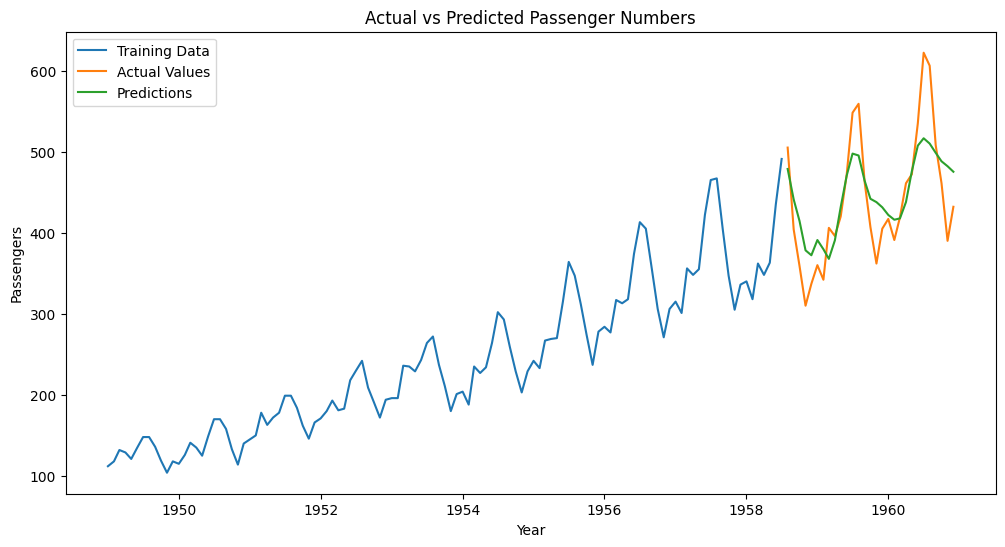

In [14]:
# Plotting Predictions vs Actual
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Values")
plt.plot(predictions.index, predictions, label="Predictions")

plt.title("Actual vs Predicted Passenger Numbers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()

plt.show()

In [15]:
# Model Evaluation (MSE)
mse = mean_squared_error(test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 2165.296114487978
